<a href="https://colab.research.google.com/github/florcisco/Online-Retail-Analysis/blob/main/Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto: Churn Prediction
Autor: Francisco Lombroni

En este analisis, buscaremos predecir la posibilidad de churn, es decir, de cambio, en este caso, usando un data set de clientes de telecomunicaciones.

## Carga del dataset

In [1]:
from google.colab import files
uploaded = files.upload()


Saving churn_prediction.csv to churn_prediction.csv


## Importación de librerías

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler


In [3]:
df = pd.read_csv('churn_prediction.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Análisis Exploratorio de Datos (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Como podemos observar, nuestro dataset contiene diversa información de cada cliente, desde distintos servicios contratados, distinta modalidad de contratación, la edad y el tiempo que lleva en la empresa. Además, encontramos en una de las columnas justamente el "Churn", es decir, si el cliente siguió o no en la empresa.

A continuación, veremos la distribución de este "Churn".

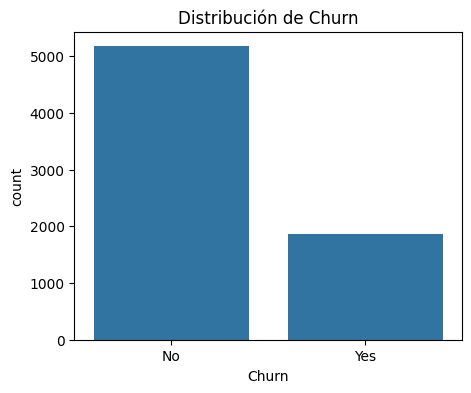

,proportion
Churn,
No,0.73463
Yes,0.26537


In [5]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn')
plt.title("Distribución de Churn")
plt.show()

df['Churn'].value_counts(normalize=True)


Como observamos, la mayoría de los clientes no hizo churn, es decir, siguió con la compañia. Situación típica, por lo que podemos usar este dataset para entrenar nuestros modelos.

También observamos que la columna TotalCharges, que debería ser numérica, está guardada como objeto, por lo que la convertiremos a numero y veremos si tenemos valores vacíos.

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()


np.int64(11)

In [7]:
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df = df.dropna(subset=['TotalCharges'])

Como tenemos algunos valores vacios en TotalCharges, que no son muchos, los descartaremos directamente.

Continuaremos viendo la relación de nuestra variable objetivo, "Churn", con las demás, separándo las variables categóricas de las numéricas.

### Variables Numericas

En primer medida, veremos la distribución de churn respecto de las variables numéricas. En este caso, tenemos cuatro variables, que son los gastos mensuales, el total de la factura, el tiempo de permanencia en la empresa y si son personas mayores de 65 o no (esto es lo que nos dice la columna SeniorCitizen, diciendo solamente "sí", 1, o "no", 0).

In [9]:
df.groupby('Churn')[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']].mean()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
Churn,,,,
No,37.650010,61.307408,2555.344141,0.128995
Yes,17.979133,74.441332,1531.796094,0.254682


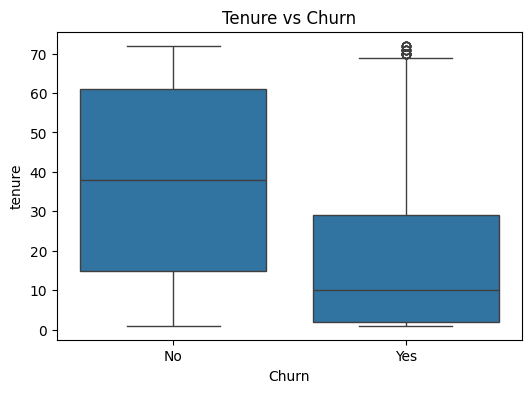

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title("Tenure vs Churn")
plt.show()

Como es de imaginar, en el gráfico de caja se observa que mientras más tiempo lleva en la compañia, menos frecuente es que se vayan, y viceversa. Lo mismo observaremos en el caso de los cargos mensuales, a mayores cargos, son más los clientes que cambian la compañía,a menor valor de la factura, es más frecuente que se queden.

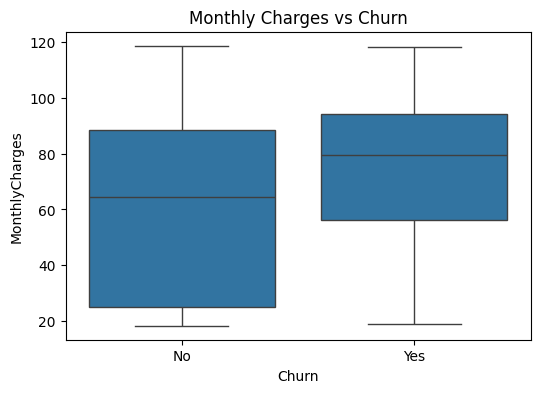

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges vs Churn")
plt.show()

### Variables Categoricas

In [12]:
categorical_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

Como observamos, encontramos muchas más variables categóricas, por lo que haremos un mapa de calor para visualizar de mejor manera la relación que hay entre cada una y la posibilidad de churn. Para esto, separaremos el porcentaje de clientes que sí cambiaron de empresa de los que no, en cada variable.

In [13]:
heatmap_data = []

categorical_features_for_heatmap = [c for c in categorical_cols if c != 'Churn']

for col in categorical_features_for_heatmap:
    counts = df.groupby([col, 'Churn']).size().reset_index(name='count')

    counts['percent'] = (
        counts['count'] /
        counts.groupby(col)['count'].transform('sum')
    ) * 100

    counts['label'] = col + " | " + counts[col].astype(str)

    heatmap_data.append(
        counts.pivot(index='label', columns='Churn', values='percent')
    )

heatmap_df = pd.concat(heatmap_data)

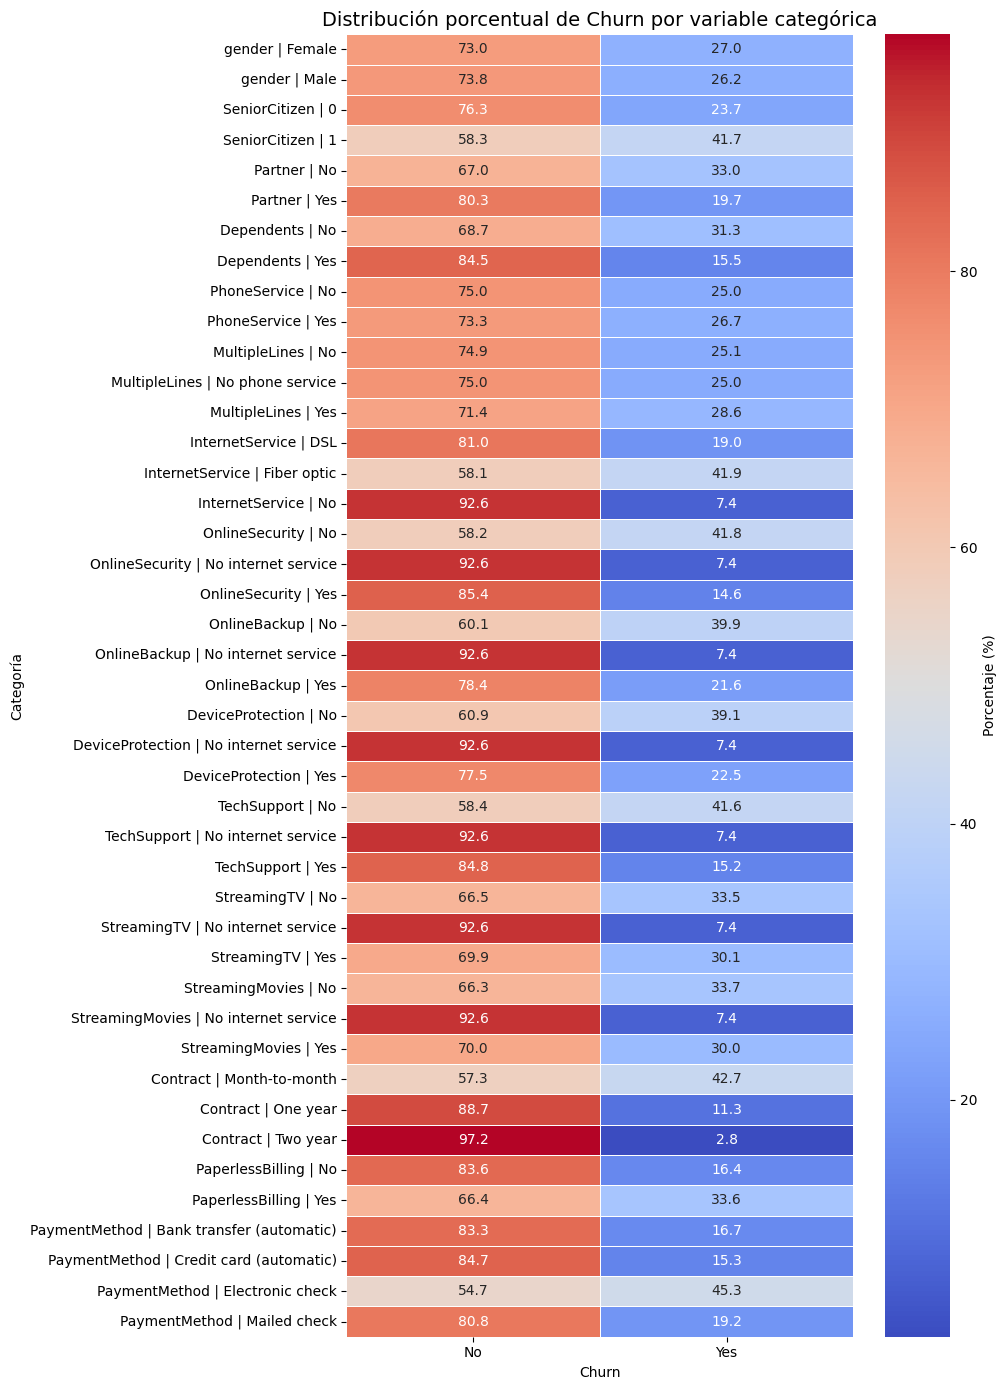

In [14]:
plt.figure(figsize=(10, 14))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={'label': 'Porcentaje (%)'}
)

plt.title("Distribución porcentual de Churn por variable categórica", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

Para observar los porcentajes obtenidos, podemos tener en cuenta que partimos de la base que teniamos una distribución de 73% de No y 27% Si. Cualquier porcentaje mayor al 27, indica una influencia importante en que sí se cambia. Estas serían las variables categóricas que más influencia pueden tener. Se destacan el método de pago, cuando es electrónico, el contrato mes a mes, el no uso del servicio técnico, el caso de gente mayor a 65 y el uso de muchos de los servicios extras.

## Creación de Modelo

Una vez analizado el dataset, pasamos a la creación del modelo. Para esto, haremos one hot encoding para clasificar las variables categóricas, separando nuestra variable objetivo, "Churn", como Y, y el resto del dataset en X. También, transformaremos los valores de No en 0 y Si en 1.

Luego, estandarizaremos las variables numericas, escalandolas.

In [17]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_encoded = pd.get_dummies(X, drop_first=True)

In [18]:
num_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

scaler = StandardScaler()
X_encoded[num_features] = scaler.fit_transform(X_encoded[num_features])

Continuamos con la selección de variables para nuestro modelo. Para esto, plantearemos primero el listado de correlación, para ver cuanto influye cada una a nuestra variable objetivo, Churn. Cuanto mayor sea el valor de correlación, mayor será la influencia de dicha variable.

In [19]:
y_encoded = y.map({'No': 0, 'Yes': 1})

correlation = pd.DataFrame({
    'feature': X_encoded.columns,
    'correlation': X_encoded.corrwith(y_encoded)
}).sort_values(by='correlation', key=abs, ascending=False)

correlation.head(20)

,feature,correlation
tenure,tenure,-0.354049
InternetService_Fiber optic,InternetService_Fiber optic,0.307463
Contract_Two year,Contract_Two year,-0.301552
PaymentMethod_Electronic check,PaymentMethod_Electronic check,0.301455
DeviceProtection_No internet service,DeviceProtection_No internet service,-0.227578
TechSupport_No internet service,TechSupport_No internet service,-0.227578
StreamingTV_No internet service,StreamingTV_No internet service,-0.227578
OnlineBackup_No internet service,OnlineBackup_No internet service,-0.227578
StreamingMovies_No internet service,StreamingMovies_No internet service,-0.227578
OnlineSecurity_No internet service,OnlineSecurity_No internet service,-0.227578


Para complementar el listado anterior, plantearemos ahora un Random Forest, para ver la importancia de cada una de las variables.

In [20]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_encoded, y)

importances = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

importances.head(10)

,feature,importance
3,TotalCharges,0.102766
1,tenure,0.097854
2,MonthlyCharges,0.079830
7041,InternetService_Fiber optic,0.022697
7059,PaymentMethod_Electronic check,0.022369
7056,Contract_Two year,0.021595
7044,OnlineSecurity_Yes,0.021191
7055,Contract_One year,0.019909
7050,TechSupport_Yes,0.019539
7057,PaperlessBilling_Yes,0.018015


In [21]:
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

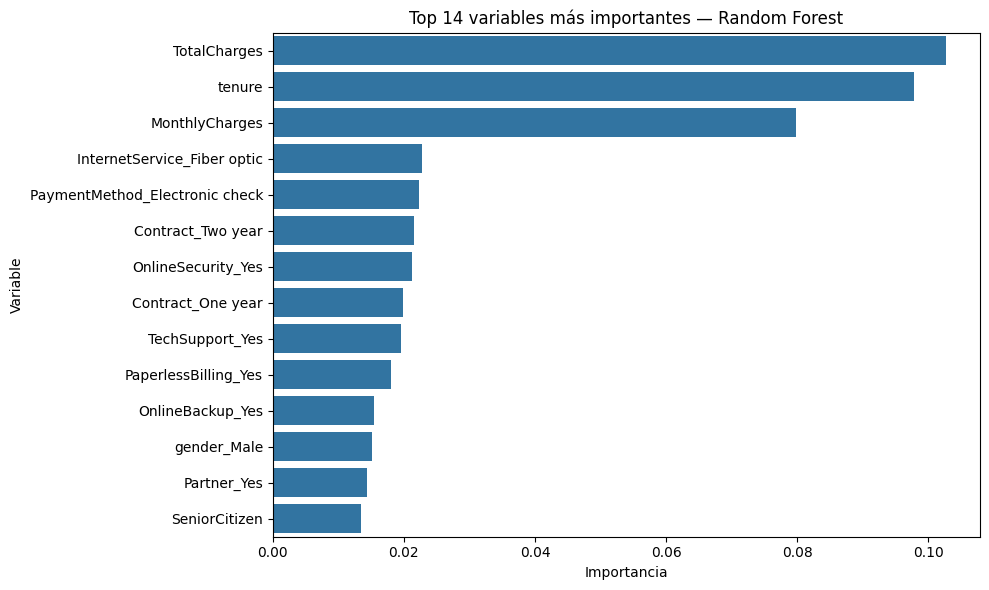

In [22]:
top_n = 14
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 14 variables más importantes — Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

Finalmente, podemos observar que entre las variables que encontramos con mayor correlación y las que obtuvimos del random forest con mayor importancia hay considerable diferencia. En este punto, vamos a observar ambos listados de las variables con mas correlación e importancia.

In [23]:
# Seleccionar las 14 variables más correlacionadas
top_14_corr = correlation.iloc[0:14]
top_14_corr

,feature,correlation
tenure,tenure,-0.354049
InternetService_Fiber optic,InternetService_Fiber optic,0.307463
Contract_Two year,Contract_Two year,-0.301552
PaymentMethod_Electronic check,PaymentMethod_Electronic check,0.301455
DeviceProtection_No internet service,DeviceProtection_No internet service,-0.227578
TechSupport_No internet service,TechSupport_No internet service,-0.227578
StreamingTV_No internet service,StreamingTV_No internet service,-0.227578
OnlineBackup_No internet service,OnlineBackup_No internet service,-0.227578
StreamingMovies_No internet service,StreamingMovies_No internet service,-0.227578
OnlineSecurity_No internet service,OnlineSecurity_No internet service,-0.227578


In [24]:
# Variables más correlacionadas con 'Churn'
top_14_corr_variables = top_14_corr.index

# Variables más importantes en Random Forest
top_rf_features = top_features.head(14)['Feature']

comparison_df = pd.DataFrame({
    'Correlated with Churn': top_14_corr_variables,
    'Random Forest Importance': top_rf_features
})

comparison_df

,Correlated with Churn,Random Forest Importance
3,tenure,TotalCharges
1,InternetService_Fiber optic,tenure
2,Contract_Two year,MonthlyCharges
7041,PaymentMethod_Electronic check,InternetService_Fiber optic
7059,DeviceProtection_No internet service,PaymentMethod_Electronic check
7056,TechSupport_No internet service,Contract_Two year
7044,StreamingTV_No internet service,OnlineSecurity_Yes
7055,OnlineBackup_No internet service,Contract_One year
7050,StreamingMovies_No internet service,TechSupport_Yes
7057,OnlineSecurity_No internet service,PaperlessBilling_Yes


Si observamos ambos listados, vemos que excepto "permanencia" ("tenure"), que se encuentra en el top de ambos listados, en lo demás difieren bastante. Cabe destacar que, si bien ambos listados son importantes para ver la influencia en "Churn", ambos ven distintos puntos de vista.

Por un lado, la correlación ve relaciones lineales y bivariadas solamente, sin influencias cruzadas. Por el otro, el random forest mide la importancia de una variable al tomar decisiones. Analiza cruzamientos entre variables, cómo cada una reduce el árbol de posibilidades, los errores, observa relaciones no lineales.

Por todo esto, veremos la intersección entre ambas listas.

In [25]:
features_corr = top_14_corr.index.tolist()
features_rf = top_features['Feature'].head(14).tolist()
features_combined = list(set(features_corr + features_rf))

corr_set = set(top_14_corr.index)
rf_set = set(top_features.head(14)['Feature'])

intersection = corr_set.intersection(rf_set)
intersection

{'Contract_Two year',
 'InternetService_Fiber optic',
 'MonthlyCharges',
 'PaperlessBilling_Yes',
 'PaymentMethod_Electronic check',
 'TotalCharges',
 'tenure'}

Estas son las variables mejor posicionadas en ambos analisis. Finalmente, para continuar, transformamos las columnas que digan Si en 1, No en 0. Y aplicamos one-hot encoding.

In [26]:
yes_no_cols = [
    'Churn',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'SeniorCitizen'
]

df[yes_no_cols] = df[yes_no_cols].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_11611/1173623687.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[yes_no_cols] = df[yes_no_cols].replace({'Yes': 1, 'No': 0})


In [27]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,False,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,False,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,False,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False


Terminado el one hot encoding, ahora podemos pasar al modelado, separando el dataset en variable objetivo ('Churn') y variables predictoras (las demás que no son 'Churn'). Según esto, construiremos nuestro modelo.

Para esto, también separaremos cada una de estas variables en dos, uno para entrenamiento del modelo y otro para su evaluación. Dado que tenemos una gran diferencia entre los clientes que se quedaron en la empresa y los que no, para que estos nuevos grupos sean representativos lo haremos de manera estratificada. Así, ya sea en el grupo de entrenamiento o de testeo, mantendremos la proporción de churn vista originalmente.

In [28]:
# Variable objetivo
y = df_encoded['Churn']

# Variables predictoras
X = df_encoded.drop(columns=['Churn'])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

### Logistic Regression

Para iniciar, empezaremos con un modelo de regresión lógica. Como este modelo se basa en los valores de cada variables, para que ninguna tenga mayor peso que la otra simplemente por sus valores especificos, usaremos el escalado de Python para estandarizar estos valores.

Además, como estamos haciendo un analisis de perdida de clientes, cabe destacar que, en este caso, es más importante perder un cliente que tal vez "molestar" a un cliente que ya tenemos. Por esto, para este modelo, priorizaremos la sensibilidad en detectar posibles casos de perdida, por lo que observaremos principalmente recall y AUC a la hora de evaluar modelos. Siguiendo esta logica para empezar, usaremos un peso de clases balanceado y un valor limite de 0.1.

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
log_reg = LogisticRegression(max_iter=10000, random_state=1, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000, random_state=1)

In [32]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8009950248756219
Precision: 0.706140350877193
Recall: 0.4304812834224599
F1: 0.5348837209302325
ROC AUC: 0.825802009618421


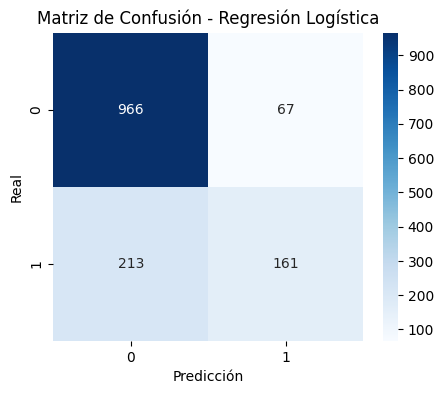

In [41]:
cm_lr = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de Confusión - Regresión Logística")
plt.show()

In [42]:
TN, FP, FN, TP = cm_lr.ravel()
total_errores = FP + FN
porc_fp = FP / total_errores
porc_fn = FN / total_errores

print(f"Total de errores: {total_errores}")
print(f"Falsos Positivos (FP): {FP} ({porc_fp:.2%})")
print(f"Falsos Negativos (FN): {FN} ({porc_fn:.2%})")

Total de errores: 280
Falsos Positivos (FP): 67 (23.93%)
Falsos Negativos (FN): 213 (76.07%)


En este primer modelo de regresión, vemos que tenemos una buena precisión y AUC, pero un recall bastante bajo, lo cual en el caso de 'Churn' es muy importante. Esto queda en evidencia en la matriz de confusión, donde observamos que de los 280 errores del modelo, la mayoría fueron "Falsos Negativos", es decir, el modelo predijo que no harían "Churn", y sí lo hicieron. Esto es lo más grave para el modelo, ya que no predijo la perdida de estos clientes.

Para esto, mejoraremos el umbral y veremos los cambios.

In [43]:
threshold_lr = 0.1
y_pred_lr_thresh = (y_prob >= threshold_lr).astype(int)

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr_thresh))
print("Precision:", precision_score(y_test, y_pred_lr_thresh))
print("Recall:", recall_score(y_test, y_pred_lr_thresh))
print("F1:", f1_score(y_test, y_pred_lr_thresh))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.751954513148543
Precision: 0.5241779497098646
Recall: 0.7245989304812834
F1: 0.6083052749719416
ROC AUC: 0.825802009618421


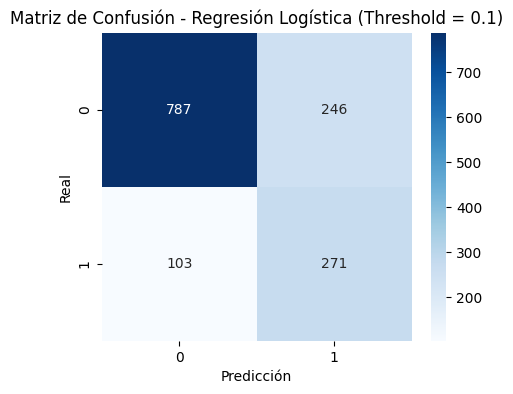

In [45]:
cm_lr_thresh = confusion_matrix(y_test, y_pred_lr_thresh)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr_thresh, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de Confusión - Regresión Logística (Threshold = {threshold_lr})")
plt.show()

In [46]:
TN, FP, FN, TP = cm_lr_thresh.ravel()
total_errores = FP + FN
porc_fp = FP / total_errores
porc_fn = FN / total_errores

print(f"Total de errores: {total_errores}")
print(f"Falsos Positivos (FP): {FP} ({porc_fp:.2%})")
print(f"Falsos Negativos (FN): {FN} ({porc_fn:.2%})")

Total de errores: 349
Falsos Positivos (FP): 246 (70.49%)
Falsos Negativos (FN): 103 (29.51%)


Ajustando el umbral, vemos que aumentó la cantidad de errores en total, pero mejoró drasticamente el porcentaje de falsos negativos. Esto queda en evidencia en la disminución de la precisión, se mantiene el AUC, pero mejora drasticamente el recall. Esto es lo más importante en "Churn", ya que como dijimos antes, es más importante predecir y mantener los clientes que tenemos.

Para ver la evolución según estos indicadores, haremos un grafico de precisión y recall según el threshold.

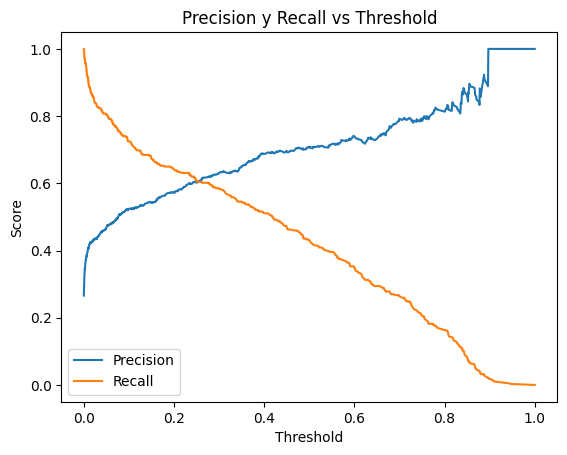

In [51]:
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

thresholds = np.append(thresholds, 1)

plt.figure()
plt.plot(thresholds, precision, label="Precision")
plt.plot(thresholds, recall, label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision y Recall vs Threshold")
plt.legend()

plt.show()

Observamos que como debería ser, baja el recall a medida que aumenta la precisión. Podemos observar un cruzamiento un poco más arriba de 0.2 de threshold, que sería un buen punto de equilibrio, pero en nuestro caso nos interesa más el recall.

Por esto, buscaremos un valor de umbral más bajo, dando mayor importancia al recall. Para elegir, haremos una tabla según el threshold, entre 0.01 y 0.19, con la precisión, el recall y el f1 para cada valor de threshold. No graficaremos AUC, que es igual de importante en nuestro caso, ya que por la forma en que se calcula no cambia para todo el modelo, y se mantiene en 0.82

In [54]:
thresholds = np.linspace(0.01, 0.19, 18)

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    print(f"Threshold: {t:.2f} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}")

Threshold: 0.01 | Precision: 0.41 | Recall: 0.91 | F1: 0.56
Threshold: 0.02 | Precision: 0.43 | Recall: 0.86 | F1: 0.57
Threshold: 0.03 | Precision: 0.44 | Recall: 0.83 | F1: 0.57
Threshold: 0.04 | Precision: 0.46 | Recall: 0.81 | F1: 0.58
Threshold: 0.05 | Precision: 0.47 | Recall: 0.80 | F1: 0.60
Threshold: 0.06 | Precision: 0.48 | Recall: 0.78 | F1: 0.60
Threshold: 0.07 | Precision: 0.50 | Recall: 0.76 | F1: 0.60
Threshold: 0.08 | Precision: 0.51 | Recall: 0.74 | F1: 0.60
Threshold: 0.09 | Precision: 0.52 | Recall: 0.74 | F1: 0.61
Threshold: 0.11 | Precision: 0.52 | Recall: 0.72 | F1: 0.60
Threshold: 0.12 | Precision: 0.53 | Recall: 0.70 | F1: 0.60
Threshold: 0.13 | Precision: 0.53 | Recall: 0.69 | F1: 0.60
Threshold: 0.14 | Precision: 0.54 | Recall: 0.68 | F1: 0.60
Threshold: 0.15 | Precision: 0.54 | Recall: 0.68 | F1: 0.61
Threshold: 0.16 | Precision: 0.55 | Recall: 0.66 | F1: 0.60
Threshold: 0.17 | Precision: 0.56 | Recall: 0.65 | F1: 0.60
Threshold: 0.18 | Precision: 0.56 | Reca

Con estos valores, podríamos elegir cualquier umbral que tenga un recall alto, ya que tenemos un F1 score bastante igual y las diferencias en precisión no son considerables tampoco. Según la situación y el costo económico de retener clientes, se podría mover algo más arriba o más abajo el umbral. Para un análisis general, con un valor umbral de 0.07 o 0.08 sería bueno.

### RANDOM FOREST

Terminado el análisis de regresión lógica, probaremos ahora un random forest. Al igual que antes, usaremos un modelo con clases balanceadas.

In [55]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

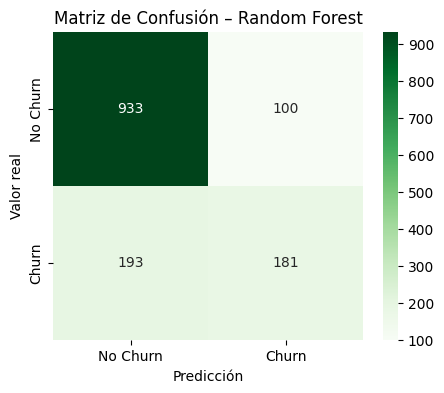

In [56]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión – Random Forest')
plt.show()

In [68]:
TN, FP, FN, TP = cm_rf.ravel()
total_errores = FP + FN
porc_fp = FP / total_errores
porc_fn = FN / total_errores

print(f"Total de errores: {total_errores}")
print(f"Falsos Positivos (FP): {FP} ({porc_fp:.2%})")
print(f"Falsos Negativos (FN): {FN} ({porc_fn:.2%})")

Total de errores: 293
Falsos Positivos (FP): 100 (34.13%)
Falsos Negativos (FN): 193 (65.87%)


Veremos que para iniciar, tenemos más o menos la misma cantidad de errores que al principio teniamos en la regresión lógica, pero mejor porcentaje de falsos negativos.

Buscaremos mejorar el bosque de decisión, especificando algunas features del modelo. Usaremos un bosque un poco más grande, limitando las caracteristicas de cada arbol.

In [58]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=2
)

rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, random_state=42)

In [59]:
y_pred_rf_tuned = rf_tuned.predict(X_test)

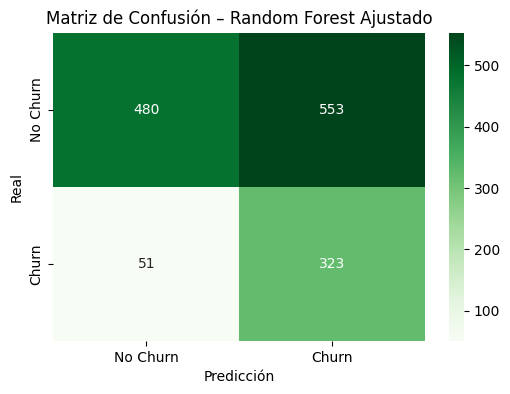

In [66]:
cm = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión – Random Forest Ajustado')
plt.show()


Vemos una clara mejoría en la predicción de falsos negativos, pero un aumento considerable también en falsos positivos. Si bien en nuestro análisis los primeros tienen más peso, no es de subestimar que tiene una cantidad de errores considerables.

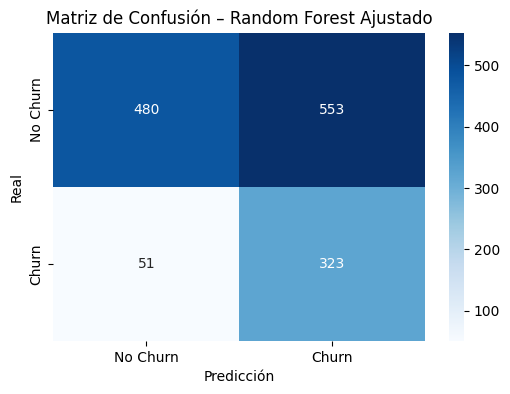

In [65]:
rf_tuned = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=3
)

rf_tuned.fit(X_train, y_train)

y_pred_rf_tuned = rf_tuned.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión – Random Forest Ajustado')
plt.show()

In [63]:
# Modelo base
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'  # MUY importante para churn
)

# Grid de hiperparámetros
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}


In [64]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=4,
    n_jobs=-1,
    verbose=2
)

# Entrenamos
grid_search.fit(X_train, y_train)


Fitting 4 folds for each of 48 candidates, totalling 192 fits


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1', verbose=2)

In [ ]:
grid_search.best_params_

{'max_depth': 20,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [ ]:
best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1033
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



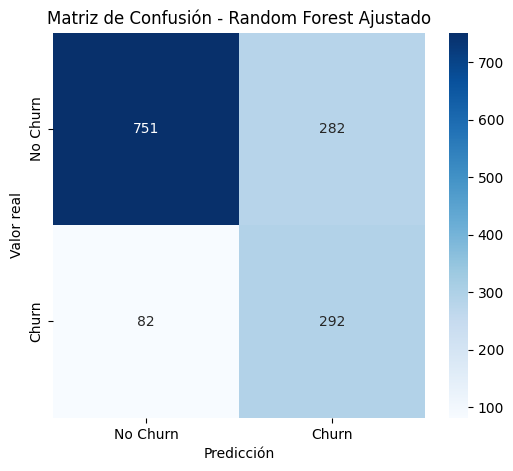

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Random Forest Ajustado')
plt.show()


In [ ]:
# Metrics for the base Random Forest model (from cell T897gimNeCAj output)
rf_recall_base = 0.51
rf_f1_base = 0.56

# Metrics for the best Random Forest model after GridSearchCV (y_pred_rf is from best_rf.predict(X_test))
rf_recall_tuned = recall_score(y_test, y_pred_rf)
rf_f1_tuned = f1_score(y_test, y_pred_rf)

rf_comparison = pd.DataFrame({
    'Modelo': ['RF Base', 'RF Ajustado'],
    'Recall': [rf_recall_base, rf_recall_tuned],
    'F1': [rf_f1_base, rf_f1_tuned]
})

rf_comparison

,Modelo,Recall,F1
0,RF Base,0.510000,0.560000
1,RF Ajustado,0.780749,0.616034


In [ ]:
# Probabilidades de churn (clase 1)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]


In [ ]:
import numpy as np

threshold = 0.3
y_pred_rf_thresh = (y_proba_rf >= threshold).astype(int)


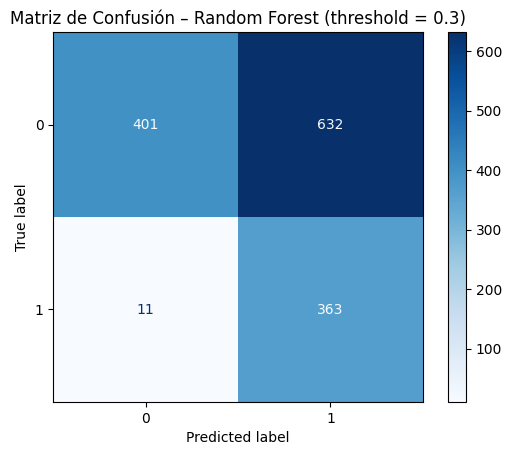

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf_thresh)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Matriz de Confusión – Random Forest (threshold = {threshold})")
plt.show()


In [ ]:
print(classification_report(y_test, y_pred_rf_thresh))


              precision    recall  f1-score   support

           0       0.97      0.39      0.56      1033
           1       0.36      0.97      0.53       374

    accuracy                           0.54      1407
   macro avg       0.67      0.68      0.54      1407
weighted avg       0.81      0.54      0.55      1407



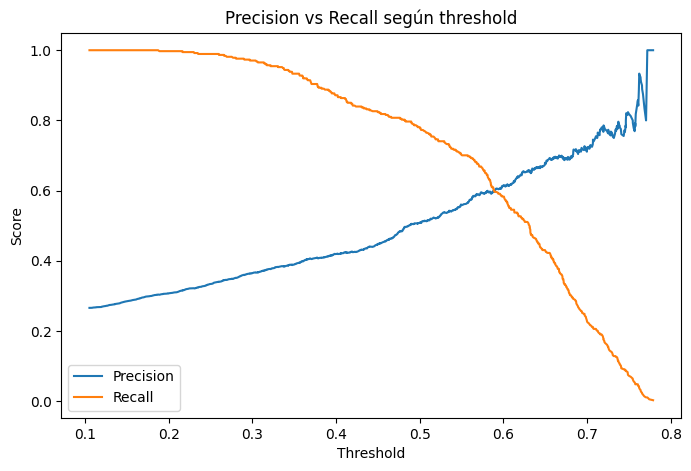

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_rf)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall según threshold")
plt.legend()
plt.show()


In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)

    print(f"Threshold {t}")
    print(f"  Recall   : {recall:.3f}")
    print(f"  Precision: {precision:.3f}")
    print("-"*30)


Threshold 0.3
  Recall   : 0.971
  Precision: 0.365
------------------------------
Threshold 0.4
  Recall   : 0.872
  Precision: 0.420
------------------------------
Threshold 0.5
  Recall   : 0.781
  Precision: 0.509
------------------------------
Threshold 0.6
  Recall   : 0.583
  Precision: 0.616
------------------------------


In [ ]:
best_rf.predict(X_test)

array([0, 1, 0, ..., 0, 0, 0])

In [ ]:
best_rf.predict_proba(X_test)[:, 1]


array([0.25307751, 0.66655746, 0.18021436, ..., 0.26477205, 0.27693182,
       0.13828569])

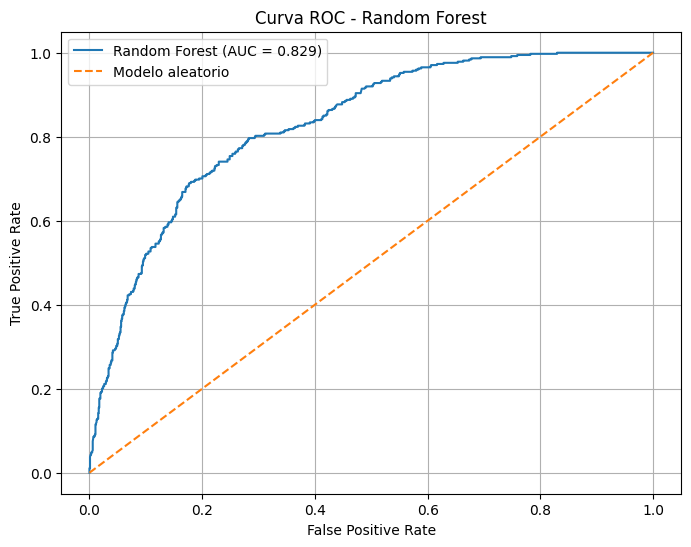

In [ ]:
# Probabilidades de churn (clase 1)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Calcular FPR, TPR y thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# Calcular AUC
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Graficar
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0,1], [0,1], linestyle='--', label='Modelo aleatorio')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


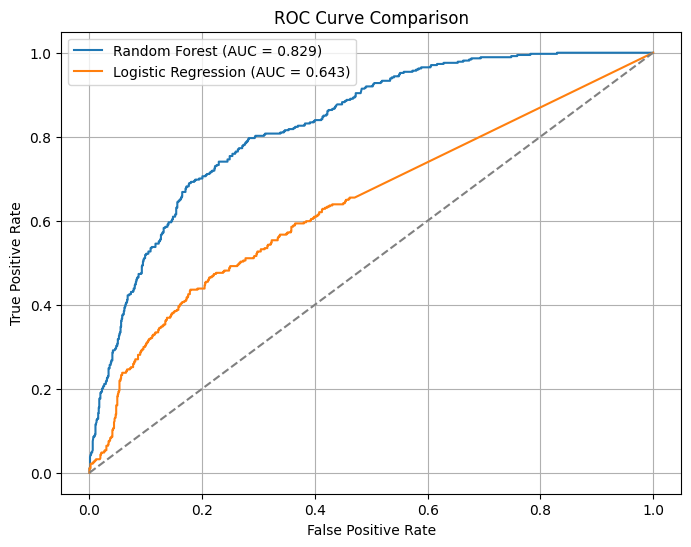

In [ ]:
# Logistic
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()
